# messing around with decomposing l05 into large & small scales


In [153]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy
from scipy.io import loadmat

from DAPyr.MISC import rkhs_likelihood
from DAPyr.MODELS import deconstruct_Z_circulant
from ipywidgets import *

reload(dap)

np.set_printoptions(suppress=True)


In [154]:
uoep = {'mu': 0, 'sigma': 1.0} 
poep = {'mu': 0, 'sigma': 1.0} 
uoep_small_sc = {'mu': 0, 'sigma': 0.01} 
poep_small_sc = {'mu': 0, 'sigma': 0.01} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}

params = {'s': 10, 'r': 28, 'b':8/3, 'F': 8, 
          'l05_F':15, 'l05_Fe':15,
          'l05_K':32, 'l05_I':12, 
          'l05_b':10.0, 'l05_c':5.0}



## step 1: initial crack at data driven approach. 

In [3]:
e_name = 'L96: sdg'
print(f'starting experiment {e_name}')
bw = 0.02
knn = 0.1
# original experiments!
e_sd_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':2,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'Ne':80,
                       'T': 500,
                       'split_l05_state': True,
                       'T_train': 50,
                       'train_frac': 1.0,
                       'nle_type': 4,
                       'Nb': 8,
                       'small_win': 5,
                       'nle_every': 100, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})



starting experiment L96: sdg


DB: Starting cycle 0
DB: Starting cycle 20
DB: Starting cycle 40
DB: Starting cycle 60
DB: Starting cycle 80
DB: Starting cycle 100
DB: Starting cycle 120
DB: Starting cycle 140
DB: Starting cycle 160
DB: Starting cycle 180
DB: Starting cycle 200
DB: Starting cycle 220
DB: Starting cycle 240
DB: Starting cycle 260
DB: Starting cycle 280
DB: Starting cycle 300
DB: Starting cycle 320
DB: Starting cycle 340
DB: Starting cycle 360
DB: Starting cycle 380
DB: Starting cycle 400
DB: Starting cycle 420
DB: Starting cycle 440
DB: Starting cycle 460
DB: Starting cycle 480


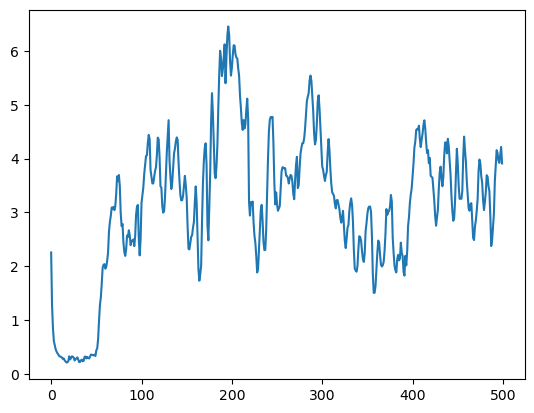

In [4]:
dap.runDA(e_sd_kecd)

### this doesn't seem very good (see below)

<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L96: sdg'}, xlabel='$y$', ylabel='$p(y | x)$'>

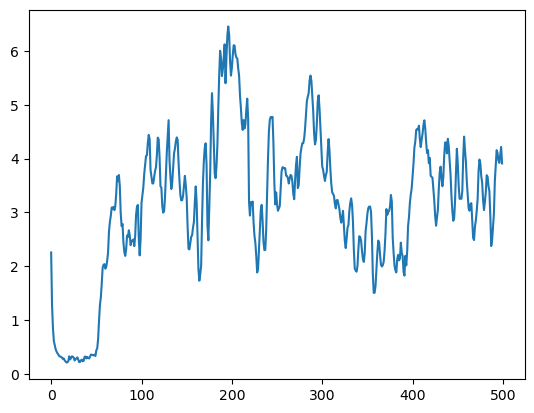

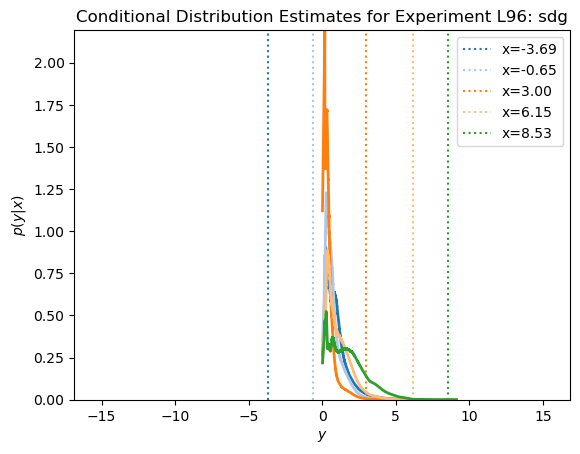

<Figure size 640x480 with 0 Axes>

In [34]:
plt.plot(e_sd_kecd.rmse)
dap.plot_pab(e_sd_kecd, plot_states=True)

### how does it compare with doing no DA? favorably I guess, but it still seems pretty bad.

In [8]:
e_name = 'l05-noda-split'
print(f'starting experiment {e_name}')
bw = 0.02
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_noda = dap.Expt(e_name, {'expt_flag': 2,
                       'model_flag':2,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'Ne':80,
                       'T': 500,
                       'split_l05_state': True,
                       'T_train': 50,
                       'debug_nle_noDA': False})


starting experiment l05-gauss-split


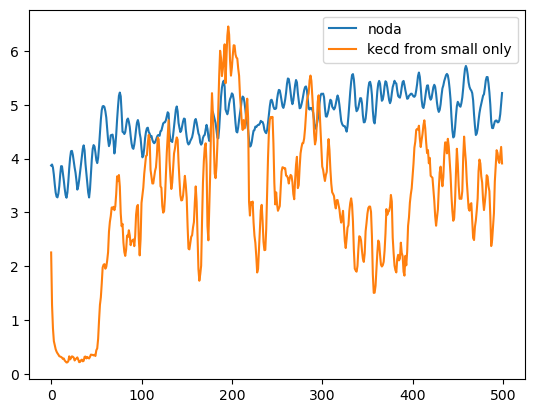

In [33]:
plt.plot(e_sd_noda.rmse, label='noda')
plt.plot(e_sd_kecd.rmse, label='kecd from small only')
plt.legend()

## OK - what about assimilating these obs directly, with knowledge of the correct forward operator?

In [155]:
e_name = 'l05-true-split'
print(f'starting experiment {e_name}')
#bw = 0.02
#knn = 0.1
klb=0.0
obf=10
small_win=4
e_split_true = dap.Expt(e_name, {'expt_flag': 1,
                       'model_flag':2,
                       'model_params': params,
                       'localize':1,
                       'obf': obf,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 3,
                       'tau': 1,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_small_sc,
                       'prescribed_obs_err_params': poep_small_sc,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'small_win': small_win,
                       'kddm_flag': 1,
                       'Ne':80,
                       'T': 500,
                       'split_l05_state': False,
                       'saveForecastEns': True,
                       'saveEnsMean': True,
                       'debug_nle_noDA': False})

e_name = 'l05-noda-split'

e_split_noda = dap.Expt(e_name, {'expt_flag': 2,
                       'model_flag':2,
                       'model_params': params,
                       'localize':1,
                       'obf': obf,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 3,
                       'tau': 1,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_small_sc,
                       'prescribed_obs_err_params': poep_small_sc,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'small_win': small_win,
                       'Ne':80,
                       'T': 500,
                       'split_l05_state': False,
                       'saveForecastEns': True,
                       'saveEnsMean': True,
                       'debug_nle_noDA': False})

starting experiment l05-true-split


In [ ]:
dap.runDA(e_split_true)
dap.runDA(e_split_noda)


DB: Starting cycle 0
DB: Starting cycle 20
DB: Starting cycle 40


In [152]:
#e_split_true = dap.loadExpt('l05-split-true.expt')
#e_split_noda = dap.loadExpt('l05-split-noda.expt')

def plot_scale_sep(t, ne, lowc, show_small_scales, show_fens_member, show_noda_ens, show_obs, show_aens_member, show_truth, show_ens_mean, show_noda_mean):

    if lowc:
        xf = e_split_true_lowc.x_fore_ens
        xa = e_split_true_lowc.x_ens
        xt = e_split_true_lowc.getStates()[1]
        Y = e_split_true_lowc.getStates()[2]
        xam = e_split_true_lowc.x_ensmean
    else:
        xf = e_split_true.x_fore_ens
        xa = e_split_true.x_ens
        xt = e_split_true.getStates()[1]
        Y = e_split_true.getStates()[2]
        xam = e_split_true.x_ensmean

    if show_truth:
        plt.plot(xt[:,t], c='k', label='truth')
        if show_obs:
            plt.scatter(np.arange(0,480,obf), Y[:,t,:], c='k', s=6)

    if show_fens_member:
        xf_smallscale = deconstruct_Z_circulant(xf[:,:,t])[1]
        hx = dap.MISC.h_weighted_mat(xf_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hx[:, ne], c='r', s=6)
        plt.plot(xf[:,ne,t], c='r', label=f'bg ens member {ne}')
        
    if show_aens_member:
        xa_smallscale = deconstruct_Z_circulant(xa[:,:,t])[1]
        hxa = dap.MISC.h_weighted_mat(xa_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hxa[:, ne], c='blue', s=6)
        plt.plot(xa[:,ne,t], c='blue', label=f'post ens member {ne}')

    if show_small_scales:
        if show_truth:
            xt_smallscale = deconstruct_Z_circulant(xt)[1]
            plt.plot(xt_smallscale[:,t], c='k', linewidth=1)
        if show_fens_member:
            plt.plot(xf_smallscale[:,ne], c='r', linewidth=1)
        if show_aens_member:
            plt.plot(xa_smallscale[:,ne], c='blue', linewidth=1)

    if show_ens_mean:
        plt.plot(xam[:,t], label='ens mean')
        
    if show_noda_mean:
        if lowc:
            plt.plot(e_split_noda_lowc.x_ensmean[:,t], label='noda mean')
        else:
            plt.plot(e_split_noda.x_ensmean[:,t], label='noda mean')

    if show_noda_ens:
        xa_noda = e_split_noda.x_ens
        plt.plot(xa_noda[:,ne,t], c='magenta', label = f'noda member {ne}')
        
        
    
    plt.legend(loc=4)
    plt.ylim(-10, 16)


interact(
    plot_scale_sep,
    t=IntSlider(min=1, max=999, step=1, value=0),
    ne=IntSlider(min=1, max=79, step=1, value=0),
    show_small_scales=Checkbox(options=['True','False'], description='plot small scale:'),
    lowc=Checkbox(options=['True','False'], description='Low coupling:'),
    show_obs=Checkbox(options=['True','False'], description='plot obs space quantities:'),
    show_fens_member=Checkbox(options=['True','False'], description='plot forecast ensemble member:'),
    show_aens_member=Checkbox(options=['True','False'], description='plot analysis ensemble member:'),
    show_ens_mean=Checkbox(options=['True','False'], description='plot ensemble mean:'),
    show_noda_mean=Checkbox(options=['True','False'], description='plot noda mean:'),
    show_noda_ens=Checkbox(options=['True','False'], description='plot noda ens members:'),
    show_truth=Checkbox(options=['True','False'], description='plot truth and obs:', value=True),
);
print(e_split_true.x_ensmean.shape)


interactive(children=(IntSlider(value=1, description='t', max=999, min=1), IntSlider(value=1, description='ne'…

(480, 10)


1
80


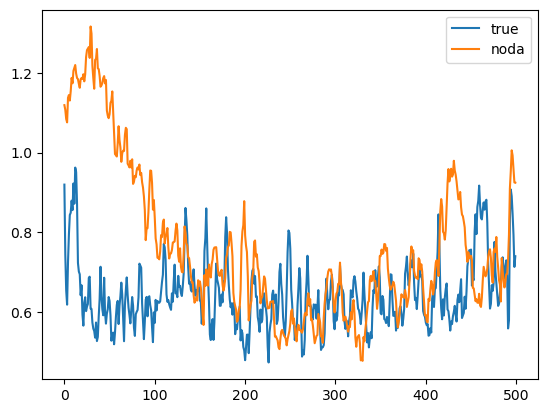

In [147]:
plt.plot(e_split_true.rmse, label='true')
plt.plot(e_split_noda.rmse, label='noda')

e_split_true.saveExpt()
e_split_noda.saveExpt()

plt.legend()


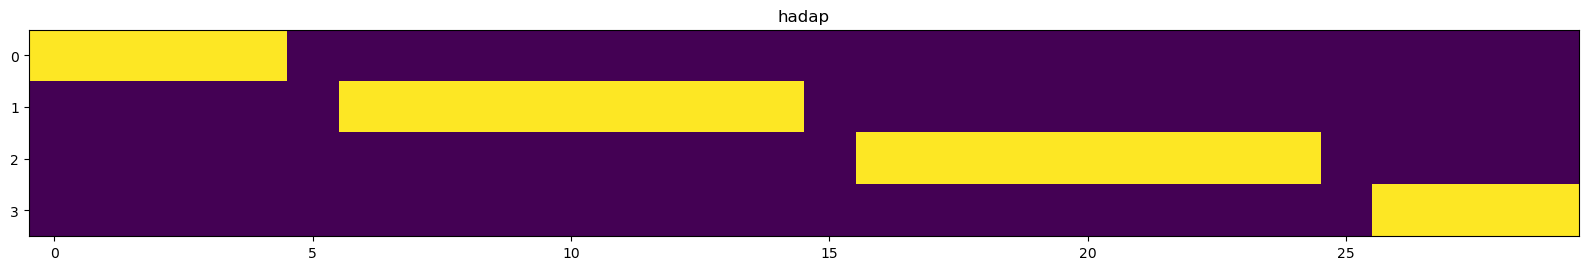

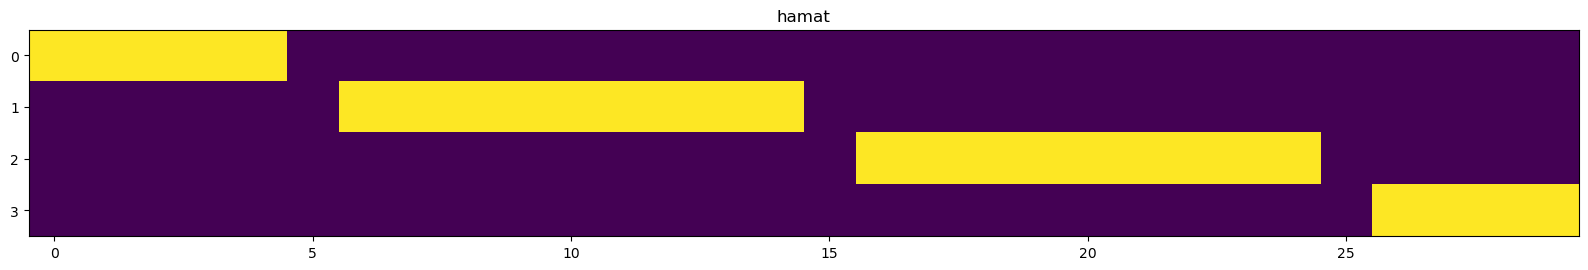

0.1
0.1
0.0
0.0
(array([0. , 0.1]), array([22608,   432]))
(array([0. , 0.1]), array([22608,   432]))
True


In [104]:
xlim=4
ylim=30
hadap = np.load('ha_dapy.npy')/10
plt.figure(figsize=(20,20))
plt.imshow(hadap[:xlim,:ylim])
plt.title('hadap')
plt.show()
hamat = loadmat('HA.mat')['HA']
plt.figure(figsize=(20,20))
plt.imshow(hamat[:xlim,:ylim])
plt.title('hamat')
plt.show()
print(hamat.max())
print(hadap.max())
print(hamat.min())
print(hadap.min())
print(np.unique(hamat, return_counts=True))
print(np.unique(hadap, return_counts=True))
print(np.allclose(hamat, hadap))




## INITIAL CONSTRUCTION OF SMALL STATE FORWARD OPERATOR/PICKING OUT TRAINING X INTERVALS

In [124]:
def h_weighted_mat(Y, h, w=3):
    Y = np.asarray(Y)
    N,k = Y.shape
    
    # 1. Determine the center indices for each step
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    
    # 2. Create the window offsets
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 3. Compute all target indices using broadcasting and modulo for periodicity
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    
    # 4. Construct the transformation matrix W of shape (M, N)
    M = len(centers)
    W = np.zeros((M, N))
    
    # Row-by-row, add 1 to the positions specified by target_indices
    row_indices = np.arange(M)[:, np.newaxis]
    np.add.at(W, (row_indices, target_indices), 1)
    
    # 5. The single matrix operation applied to |Y|
    return W @ np.abs(Y)

def x_slices(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine the center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 2. Compute periodic target indices
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    M, window_size = target_indices.shape
    
    # 3. Construct the Selection Matrix P of shape (M * window_size, N)
    total_extracted_elements = M * window_size
    P = np.zeros((total_extracted_elements, N))
    
    # Map each position in the flattened output to its corresponding index in X
    row_indices = np.arange(total_extracted_elements)
    col_indices = target_indices.ravel() # Flatten the target indices
    P[row_indices, col_indices] = 1
    
    # 4. Apply the matrix operation and reshape into the final matrix grid
    flat_slices = P @ X
    return flat_slices.reshape(M, window_size)

import numpy as np

def periodic_window_context(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (1, 2w + 1)
    
    # 2. Compute periodic target indices
    targets = (centers + offsets) % N           # Shape: (M, 2w + 1)
    M = len(centers)
    
    # 3. Construct the Context Selection Matrix P of shape (M * N, N)
    # Initialize the entire matrix with np.nan
    P = np.full((M * N, N), np.nan)
    
    # Calculate which global row indices in P correspond to valid window placements
    step_indices = np.arange(M)[:, np.newaxis]
    rows = (step_indices * N + targets).ravel()
    cols = targets.ravel()
    
    # For active rows, initialize them to 0, then set the target column to 1
    P[rows, :] = 0
    P[rows, cols] = 1
    
    # 4. Perform the single matrix multiplication and reshape to (M, N)
    flat_context = P @ X
    return flat_context.reshape(M, N)

def deconstruct_Z_circulant(Zn_matrix, I=12):
    Zn_matrix = np.asarray(Zn_matrix)
    Nx, k_cols = Zn_matrix.shape
    I = int(I)
    
    if I > 1:
        alpha = (3*I*I + 3)/(2*I*I*I + 4*I)
        beta = (2*I*I + 1)/(I*I*I*I + 2*I*I)
        
        # 1. Create the base filter weights
        offsets = np.arange(-I, I + 1)
        weights = alpha - beta * np.abs(offsets)
        weights[0] /= 2
        weights[-1] /= 2
        
        # 2. Map weights to a baseline row of length Nx using periodic modulo
        base_row = np.zeros(Nx)
        np.add.at(base_row, offsets % Nx, weights)
        
        # 3. Generate the Nx x Nx Circulant Transformation Matrix
        rows = np.arange(Nx)[:, np.newaxis]
        cols = np.arange(Nx)
        C = base_row[(cols - rows) % Nx]
        
        # 4. Apply the single matrix multiplication to all columns at once
        # (Nx x Nx) @ (Nx x k_cols) -> (Nx x k_cols)
        Xn = C @ Zn_matrix
        Yn = Zn_matrix - Xn
    else:
        Xn = Zn_matrix.copy()
        Yn = np.zeros_like(Zn_matrix)
        
    return Xn, Yn

### demo plotting - see file location

In [82]:
#for num in range(120):
#   xs = periodic_window_context(X, 4, 10)
#   plt.plot(ens1, linewidth=2, c='k')
#   plt.plot(X, c='red')
#   plt.plot(Y)
#   plt.plot(xs[num], linewidth=6, c='red')
#   plt.plot((num*4, num*4), (0,2*hy[num]), linewidth=1, c='C1')
#   plt.scatter(num*4, 2*hy[num], c='C1')
#   plt.savefig(f'../figs/l05-multiscale/demo-l05-multiscale-{num:03}.png')
#   plt.close()